# **Many Artificial LSST Lightcurves based on Observations of Real Nuclear Transients (MALLORN) - Using the Data Demonstration Notebook**

This notebook outlines the process of loading in the data for the lightcurve of a chosen object, including the relevant information about the object from the log file. It also provides a demonstration of how to split the data according to the band (u, g, r, i, z, y) and how to perform the necessary de-extinction to the lightcurve.

## **Step One** : Loading in the lightcurve data

In [18]:
# Local data paths (no Google Drive)
from pathlib import Path

DATA_ROOT = Path('datasets')
SPLIT = 'split_01'
LIGHTCURVE_PATH = DATA_ROOT / SPLIT / 'train_full_lightcurves.csv'
LOG_PATH = DATA_ROOT / 'train_log.csv'

print('Lightcurves:', LIGHTCURVE_PATH)
print('Log:', LOG_PATH)


Lightcurves: datasets/split_01/train_full_lightcurves.csv
Log: datasets/train_log.csv


### **1.1 : Importing the necessary packages**



In [19]:
#Importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Setting filter colours for later plotting
filter_colours = {'u': '#6A5ACD', 'g': '#2ca02c', 'r': '#d62728', 'i': '#ff7f0e', 'z': '#8c564b', 'y': '#1b1b1b'}

### **1.2: Loading in the lightcurve data**

In [20]:
# Insert path to lightcurve file
path = LIGHTCURVE_PATH

# Reading all lightcurve data into a dataframe
df = pd.read_csv(path)
print(df.head())


                  object_id  Time (MJD)       Flux  Flux_err Filter
0  Dornhoth_fervain_onodrim  63314.4662  -1.630159  0.365777      z
1  Dornhoth_fervain_onodrim  63780.9674  10.499389  0.253867      r
2  Dornhoth_fervain_onodrim  63789.7693   5.866250  1.559241      y
3  Dornhoth_fervain_onodrim  63794.1702   3.903623  0.376854      r
4  Dornhoth_fervain_onodrim  63794.1702   5.226644  0.516864      i


### **1.3: Isolating data for chosen object and splitting according to filter**

In [21]:
# Define name of chosen object
object_ID = 'amon_imloth_luin'

if object_ID not in df['object_id'].values:
    object_ID = df['object_id'].iloc[0]
    print('Object not found, using first object:', object_ID)

# Creating masks to isolate data for chosen lightcurve and split according to filter
u_mask = ((df['Filter'] == 'u') & (df['object_id'] == object_ID))
g_mask = ((df['Filter'] == 'g') & (df['object_id'] == object_ID))
r_mask = ((df['Filter'] == 'r') & (df['object_id'] == object_ID))
i_mask = ((df['Filter'] == 'i') & (df['object_id'] == object_ID))
z_mask = ((df['Filter'] == 'z') & (df['object_id'] == object_ID))
y_mask = ((df['Filter'] == 'y') & (df['object_id'] == object_ID))


In [22]:
# Extract per-band arrays
def band_arrays(mask):
    sub = df.loc[mask, ['Time (MJD)', 'Flux', 'Flux_err']].sort_values('Time (MJD)')
    return (
        sub['Time (MJD)'].to_numpy(),
        sub['Flux'].to_numpy(),
        sub['Flux_err'].to_numpy(),
    )

u_time, u_flux, u_err = band_arrays(u_mask)
g_time, g_flux, g_err = band_arrays(g_mask)
r_time, r_flux, r_err = band_arrays(r_mask)
i_time, i_flux, i_err = band_arrays(i_mask)
z_time, z_flux, z_err = band_arrays(z_mask)
y_time, y_flux, y_err = band_arrays(y_mask)


### **1.4: Loading in log data**

In [23]:
# Loading in log data file
log_path = LOG_PATH
log_df = pd.read_csv(log_path)

# Selecting only the data relevant to the chosen object
object_log = log_df.loc[log_df['object_id'] == object_ID]
print(object_log)

# Defining the redshift of that object
redshift = float(object_log['Z'].iloc[0])

# redshift_err = object_log['Z_err']
# For training set, it is a spectroscopically determined redshift (with negligible error).
# For testing set, it will be a photometrically determined redshift and will have an error value.

ebv = float(object_log['EBV'].iloc[0])
# Loading in the extinction coefficient value
# Dust in the Milky Way can obscure the light from a distant object.

SpecType = object_log['SpecType'].iloc[0]
# For the training set, the type of the object will be listed in the 'SpecType' column
# For the testing set, this value will not be present


           object_id       Z  Z_err    EBV SpecType  \
12  amon_imloth_luin  0.7766    NaN  0.055      TDE   

                                  English Translation     split  target  
12  hill, steep-sided mount  +  flowering valley  ...  split_01       1  


## **Step Two** : De-extincting and plotting the lightcurve data

### **2.1: Loading necessary package and defining de-extinction function**

In [24]:
#Importing necessary package
from extinction import fitzpatrick99

#Defining function to de-extinct a set of flux values
def jurassic_park (flux, eff_wl):
    A_lambda = fitzpatrick99(eff_wl, ebv * 3.1) #3.1 = Standard Milky Way value
    flux_ext = flux * 10**((A_lambda)/2.5)
    return flux_ext, A_lambda

### **2.2: De-extincting fluxes**

In [25]:
#Effective wavelength for each band - sourced from SVO Filter Profile Service
u_eff_wl = np.array([3641]); g_eff_wl = np.array([4704]); r_eff_wl = np.array([6155])
i_eff_wl = np.array([7504]); z_eff_wl = np.array([8695]); y_eff_wl = np.array([10056])

#De-extincting lightcurves
u_flux, u_A_lambda = jurassic_park(u_flux,u_eff_wl); g_flux, g_A_lambda = jurassic_park(g_flux,g_eff_wl)
r_flux, r_A_lambda = jurassic_park(r_flux,r_eff_wl); i_flux, i_A_lambda = jurassic_park(i_flux,i_eff_wl)
z_flux, z_A_lumbda = jurassic_park(z_flux,z_eff_wl) ;y_flux, y_A_lambda = jurassic_park(y_flux,y_eff_wl)

print(f'u band extinction = {u_A_lambda}'); print(f'g band extinction = {g_A_lambda}'); print(f'r band extinction = {r_A_lambda}')
print(f'i band extinction = {i_A_lambda}'); print(f'z band extinction = {z_A_lumbda}'); print(f'y band extinction = {y_A_lambda}')

u band extinction = [0.26116086]
g band extinction = [0.20746283]
r band extinction = [0.14256113]
i band extinction = [0.1049135]
z band extinction = [0.08188936]
y band extinction = [0.06363456]


### **2.3: Plotting lightcurve**

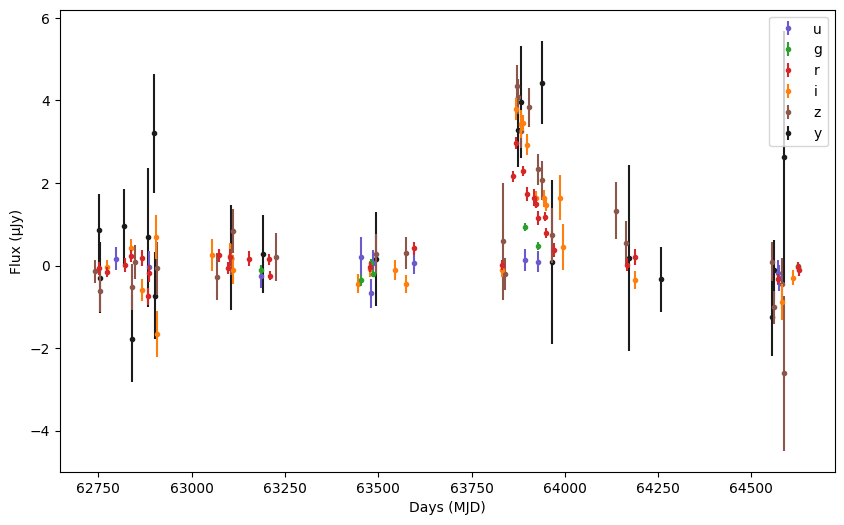

In [26]:
plt.figure(figsize = [10,6])
plt.errorbar(u_time,u_flux, yerr= u_err,label='u', fmt = '.',color = filter_colours['u'],zorder=4)
plt.errorbar(g_time,g_flux,yerr=g_err, label='g', fmt = '.', color = filter_colours['g'],zorder=5)
plt.errorbar(r_time,r_flux,yerr = r_err, label='r', fmt = '.', color = filter_colours['r'],zorder=6)
plt.errorbar(i_time,i_flux,yerr = i_err, label='i', fmt = '.', color = filter_colours['i'],zorder=3)
plt.errorbar(z_time,z_flux,yerr = z_err, label='z', fmt = '.', color = filter_colours['z'],zorder=2)
plt.errorbar(y_time,y_flux,yerr = y_err, label='y', fmt = '.', color = filter_colours['y'],zorder=1)
plt.xlabel('Days (MJD)')
plt.ylabel('Flux (μJy)')
plt.legend()
plt.show()